In [11]:
from langgraph.graph import StateGraph
from typing import Dict, TypedDict,List
import math

In [13]:
class AgentState(TypedDict):
  name:str
  values:List[int]
  operation:str
  result:str


def operationNode(state:AgentState) -> AgentState:
      """Simple node that do the operation it was  given"""

      if(state['operation'] == '+'):
        val = sum(state['values'])
      elif(state['operation'] == '*'):
        val = math.prod(state['values'])
      else:
        val = "invalid!"

      state['result'] = f"hi {state['name']},your answer is {val}"

      return state


In [14]:
graph = StateGraph(AgentState)

graph.add_node("operation",operationNode)

graph.set_entry_point("operation")
graph.set_finish_point("operation")

app = graph.compile()


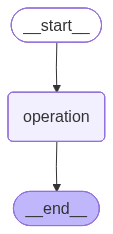

In [15]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [19]:
result = app.invoke({"name":'nayana', "operation":'+',"values":[1,2,3,4]})

In [20]:
result

{'name': 'nayana',
 'values': [1, 2, 3, 4],
 'operation': '+',
 'result': 'hi nayana,your answer is 10'}

In [21]:
result['result']

'hi nayana,your answer is 10'